# Training a multi-class classifier (Mini-batch GD, B) - PyTorch Version for MNIST

We train with mini-batch gradient descent (batch size B) using PyTorch with hooks to capture gradients and intermediate computations for multi-class classification.

In [1]:
def train_model(X_data, y_data, input_dim, num_classes, batch_size=32, lr=0.01, epochs=200, device=None, verbose=True):
    """
    Train a fresh multi-class logistic regression model from scratch.
    
    Args:
        X_data: Training features tensor [N, D]
        y_data: Training labels tensor [N]
        input_dim: Input dimension (D)
        num_classes: Number of classes
        batch_size: Mini-batch size
        lr: Learning rate
        epochs: Number of training epochs
        device: torch device (cuda/cpu)
        verbose: Print training progress
        
    Returns:
        model: Trained model
        loss_history: List of losses per epoch
        acc_history: List of accuracies per epoch
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Create fresh model
    model = MultiClassLogisticRegression(input_dim, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    N = X_data.shape[0]
    loss_history = []
    acc_history = []
    
    for epoch in range(epochs):
        # Shuffle data each epoch
        indices = torch.randperm(N)
        X_epoch = X_data[indices]
        y_epoch = y_data[indices]
        
        # Mini-batch training
        for start in range(0, N, batch_size):
            end = min(start + batch_size, N)
            X_batch = X_epoch[start:end]
            y_batch = y_epoch[start:end]
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        
        # Track full-data loss and accuracy
        with torch.no_grad():
            full_outputs = model(X_data)
            full_loss = criterion(full_outputs, y_data)
            loss_history.append(full_loss.item())
            
            # Accuracy
            _, predicted = torch.max(full_outputs, 1)
            accuracy = (predicted == y_data).float().mean().item()
            acc_history.append(accuracy)
        
        if verbose and epoch % 100 == 0:
            print(f"Epoch {epoch}: Loss = {loss_history[-1]:.4f}, Acc = {acc_history[-1]:.4f}")
    
    return model, loss_history, acc_history

Using device: cuda
Dataset: 900 samples, 784 features, 3 classes
Class distribution: tensor([300, 300, 300], device='cuda:0')

Training initial model...
Epoch 0: Loss = 0.1440, Acc = 0.9644
Epoch 100: Loss = 0.0095, Acc = 1.0000

Final Training Accuracy: 100.00%
Final Loss: 0.004959
Test Loss: 0.068063
Test Accuracy: 97.87%


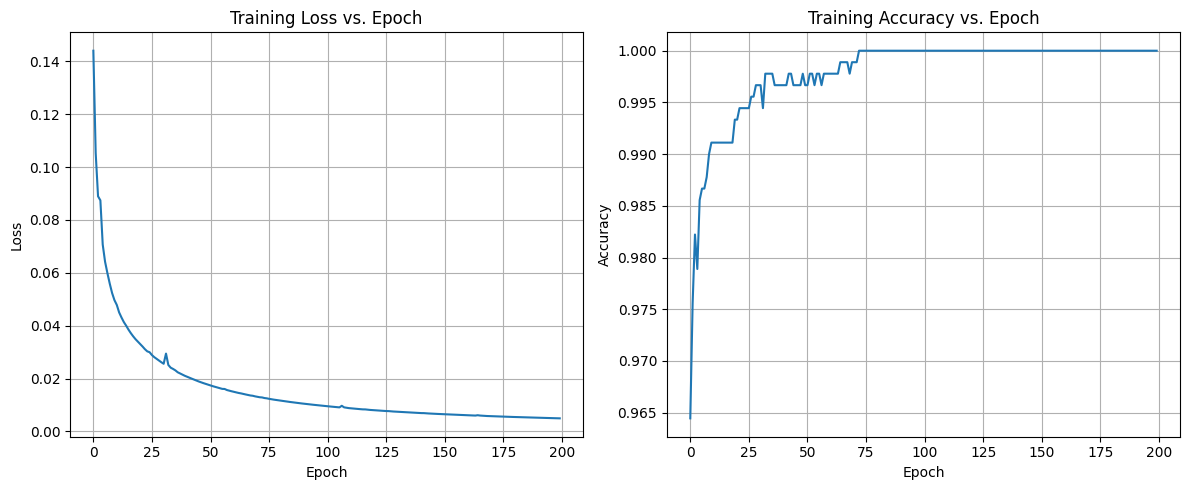


Probe point: Test index 1287
Current prediction: 2, Target class: 0
Current probabilities: [3.7895679e-04 7.0463524e-10 9.9962103e-01]
Prob for target class 0: 0.000379


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from torch.autograd import grad
from torchvision import datasets, transforms

B = 32  # batch size
RANDOM_SEED = 42

# Set device and reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Using device: {device}")

# ---- 1) Load real MNIST data ----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

def filter_mnist_classes(dataset, classes=[0, 1, 2]):
    """Filter dataset to only include specified classes"""
    indices, targets, data = [], [], []
    for i, (img, label) in enumerate(dataset):
        if label in classes:
            indices.append(i)
            targets.append(classes.index(label))
            data.append(img.flatten())
    return torch.stack(data), torch.tensor(targets)

# Filter to 3 classes and take subset
n_classes = 3
target_classes = [0, 1, 2]
X_train, y_train = filter_mnist_classes(train_dataset, target_classes)
X_test, y_test = filter_mnist_classes(test_dataset, target_classes)

# Take subset (300 samples per class)
samples_per_class = 300
subset_indices = []
for class_idx in range(n_classes):
    class_mask = y_train == class_idx
    class_indices = torch.where(class_mask)[0][:samples_per_class]
    subset_indices.extend(class_indices.tolist())

subset_indices = torch.tensor(subset_indices)
X = X_train[subset_indices]
y = y_train[subset_indices]

# Shuffle dataset
perm = torch.randperm(len(X))
X, y = X[perm], y[perm]
N, D = X.shape

# Convert to device
X_tensor, y_tensor = X.to(device), y.to(device)

print(f"Dataset: {N} samples, {D} features, {n_classes} classes")
print(f"Class distribution: {torch.bincount(y_tensor)}")

# ---- 2) Define Model ----
class MultiClassLogisticRegression(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MultiClassLogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, num_classes)
        nn.init.normal_(self.linear.weight, mean=0, std=0.01)
        nn.init.zeros_(self.linear.bias)
    
    def forward(self, x):
        return self.linear(x)

# ---- 3) Train initial model ----
print("\n" + "="*60)
print("Training initial model...")
print("="*60)
model, loss_history, acc_history = train_model(
    X_tensor, y_tensor, D, n_classes, 
    batch_size=B, lr=0.01, epochs=200, device=device, verbose=True
)

# Final metrics
with torch.no_grad():
    final_outputs = model(X_tensor)
    _, predictions = torch.max(final_outputs, 1)
    accuracy = (predictions == y_tensor).float().mean().item()

print(f"\nFinal Training Accuracy: {accuracy*100:.2f}%")
print(f"Final Loss: {loss_history[-1]:.6f}")

# Evaluate on test set
X_test_tensor, y_test_tensor = X_test.to(device), y_test.to(device)
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss = nn.CrossEntropyLoss()(test_outputs, y_test_tensor)
    _, test_predictions = torch.max(test_outputs, 1)
    test_accuracy = (test_predictions == y_test_tensor).float().mean().item()

print(f"Test Loss: {test_loss.item():.6f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(loss_history)
ax1.set_title("Training Loss vs. Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

ax2.plot(acc_history)
ax2.set_title("Training Accuracy vs. Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)

plt.tight_layout()
plt.show()

# ---- Probe (x*, y*) ----
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

test_idx = torch.randint(0, len(X_test), (1,)).item()
x_star = X_test[test_idx].to(device)

# Get current prediction
with torch.no_grad():
    logits_star = model(x_star.unsqueeze(0))
    probs_star = F.softmax(logits_star, dim=1)[0]
    current_pred = torch.argmax(probs_star).item()

# Randomly select target class (not current prediction)
other_classes = [c for c in range(n_classes) if c != current_pred]
class_star = np.random.choice(other_classes)

print(f"\n{'='*60}")
print(f"Probe point: Test index {test_idx}")
print(f"Current prediction: {current_pred}, Target class: {class_star}")
print(f"Current probabilities: {probs_star.cpu().numpy()}")
print(f"Prob for target class {class_star}: {probs_star[class_star].item():.6f}")
print(f"{'='*60}")

# Influence pipeline: IHVP via CG + Cross-Jacobian–Vector product (double-backward)

We compute

$
G_\delta \;=\; -\frac{1}{n}\,\big[\nabla_z \nabla_\theta L(z,\hat\theta)\big]^\top \underbrace{(H_{\hat\theta}+\lambda I)^{-1}\nabla_\theta f(\hat\theta)}_{v}
$

* IHVP $v$ is solved by **conjugate gradient** on the empirical-risk Hessian using **HVPs**.
* $J^\top v = [\nabla_z \nabla_\theta L]^\top v = \nabla_z\big(\nabla_\theta L \cdot v\big)$ via **one** double-backward per batch.
* Here, $z\equiv x$ (labels are fixed). For NLP, replace `x` by token **embeddings**.



In [3]:

def params_of(model):
    return [p for p in model.parameters() if p.requires_grad]

def flatten_list(tensors):
    return torch.cat([t.reshape(-1) for t in tensors])

def unflatten_like(flat_vec, like_tensors):
    out, i = [], 0
    for t in like_tensors:
        n = t.numel()
        out.append(flat_vec[i:i+n].view_as(t))
        i += n
    return out

num_params = sum(p.numel() for p in params_of(model))
print(f"#params: {num_params}")

#params: 2355


Define the query observable $f(\theta)=\log p(y^*|x^*;\theta)$ and compute $g_f=\nabla_\theta f$

We’ll take the **probe** `(x_star, class_star)` you created, and compute the gradient w.r.t. parameters.


In [4]:

def grad_theta_f_logprob(model, x_star, y_star):
    """
    ∇_θ f where f = log p(y*=y_star | x*=x_star; θ)
    Returns a list matching model.parameters().
    """
    model.eval()
    params = params_of(model)

    # Ensure params track gradients for autograd
    req_prev = [p.requires_grad for p in params]
    for p in params: p.requires_grad_(True)

    logits = model(x_star.unsqueeze(0))            # [1, K]
    logp = F.log_softmax(logits, dim=-1)[0, y_star]  # scalar
    g_list = torch.autograd.grad(logp, params, retain_graph=False, create_graph=False)

    # restore requires_grad
    for p, r in zip(params, req_prev): p.requires_grad_(r)
    return [g.detach() for g in g_list]

g_f_list = grad_theta_f_logprob(model, x_star, class_star)
g_f_flat = flatten_list(g_f_list)
print("||∇θ f||:", g_f_flat.norm().item())

||∇θ f||: 44.79412841796875



##2) Hessian–Vector Product (HVP) for the empirical risk

We implement $ H v = \nabla_\theta^2 \Big(\frac{1}{N}\sum_i \ell_i(\theta)\Big)\, v $.

**Note:** We average the loss over the **full training set** in mini-batches to keep memory small.
Add **damping** $\lambda v$ inside the HVP during CG.

In [5]:
from contextlib import nullcontext

def hvp_empirical_risk(model, data_X, data_y, v_list, batch_size=256):
    """
    Compute H v where H is the Hessian of mean cross-entropy over (data_X, data_y).
    v_list is a list shaped like model.parameters().
    """
    model.eval()
    params = params_of(model)
    # Save and set requires_grad for higher-order derivs
    req_prev = [p.requires_grad for p in params]
    for p in params: p.requires_grad_(True)

    # running sum of HVP; we'll average at the end
    hvp_sum = [torch.zeros_like(p) for p in params]

    N_total = data_X.shape[0]
    for start in range(0, N_total, batch_size):
        end = min(start + batch_size, N_total)
        xb = data_X[start:end]
        yb = data_y[start:end]

        logits = model(xb)
        loss = F.cross_entropy(logits, yb, reduction='mean')  # mean over batch for stability

        # First grad: g = ∇θ loss
        g_list = torch.autograd.grad(loss, params, create_graph=True)

        # Dot with v: s = g·v
        s = sum((gi * vi).sum() for gi, vi in zip(g_list, v_list))

        # Second grad: ∇θ s = H v (on this batch)
        hvp_batch = torch.autograd.grad(s, params, retain_graph=False)
        for acc, h in zip(hvp_sum, hvp_batch):
            acc += h.detach()

        # Free the graph for this batch
        del g_list, s, hvp_batch

    # Average across all batches (note loss was mean per batch; here we average per-batch HVPs)
    num_batches = (N_total + batch_size - 1) // batch_size
    hvp_avg = [h / num_batches for h in hvp_sum]

    # restore original requires_grad flags
    for p, r in zip(params, req_prev): p.requires_grad_(r)
    return hvp_avg

##3) Conjugate gradient solver to obtain the IHVP

We solve $(H+\lambda I) v = b$ for $v$, where $b=\nabla_\theta f$.
Each CG iteration uses **one HVP** (plus damping).

In [6]:
def cg_solve_ihvp(model, data_X, data_y, b_list, damping=1e-3, tol=1e-6, max_iter=200, batch_size=256, verbose=False):
    """
    Conjugate gradient on (H + λI) v = b.
    Returns list of tensors v_list matching params.
    """
    params = params_of(model)

    def apply_A(v_list):
        Hv = hvp_empirical_risk(model, data_X, data_y, v_list, batch_size=batch_size)
        # Add damping: (H + λ I) v
        return [h + damping * v for h, v in zip(Hv, v_list)]

    # Initialize
    v_list = [torch.zeros_like(p) for p in params]
    r_list = [b.clone() for b in b_list]                     # r = b - A*0 = b
    p_list = [r.clone() for r in r_list]                     # p = r
    rTr = sum((r*r).sum() for r in r_list)

    if verbose:
        print(f"CG iter 0: ||r||={rTr.sqrt().item():.4e}")

    for it in range(1, max_iter+1):
        Ap = apply_A(p_list)
        pAp = sum((p*a).sum() for p, a in zip(p_list, Ap))
        alpha = rTr / (pAp + 1e-12)
        # v += alpha * p; r -= alpha * A p
        for i in range(len(v_list)):
            v_list[i] = v_list[i] + alpha * p_list[i]
            r_list[i] = r_list[i] - alpha * Ap[i]

        rTr_new = sum((r*r).sum() for r in r_list)
        if verbose and (it % 10 == 0 or it == 1):
            print(f"CG iter {it}: ||r||={rTr_new.sqrt().item():.4e}")

        if rTr_new.sqrt() < tol:
            if verbose:
                print(f"CG converged in {it} iterations.")
            break

        beta = rTr_new / (rTr + 1e-12)
        for i in range(len(p_list)):
            p_list[i] = r_list[i] + beta * p_list[i]
        rTr = rTr_new

    return v_list

##4) Compute the IHVP for our probe

This yields $v \approx (H+\lambda I)^{-1}\nabla_\theta f$.  
You can later **swap this CG block** with your **EK‑FAC** `.ihvp(...)` call.


In [7]:
damping = 5e-3    # Tikhonov damping (tune as needed)
cg_tol = 1e-5
cg_max_iter = 200

with torch.no_grad():
    # Work on TRAIN set curvature
    b_list = [g.clone() for g in g_f_list]   # b = ∇θ f

# Run CG
v_list = cg_solve_ihvp(
    model, X_tensor, y_tensor, b_list,
    damping=damping, tol=cg_tol, max_iter=cg_max_iter, batch_size=256, verbose=True
)

v_flat = flatten_list(v_list)
print("||v||:", v_flat.norm().item())

CG iter 0: ||r||=4.4794e+01
CG iter 1: ||r||=5.3592e+01
CG iter 10: ||r||=1.5057e+01
CG iter 20: ||r||=1.9318e+00
CG iter 30: ||r||=8.9209e-02
CG iter 40: ||r||=1.3048e-02
CG iter 50: ||r||=5.6650e-04
CG iter 60: ||r||=5.7385e-05
CG converged in 69 iterations.
||v||: 3606.25537109375



##5) Cross-Jacobian–vector product: $J^\top v = [\nabla_x \nabla_\theta L(x,\hat\theta)]^\top v$

For a batch $(x,y)$, we compute:

$
J^\top v \;=\; \nabla_x \big( \nabla_\theta L(x,y;\hat\theta)^\top v \big)
$

using a single **double-backward**. Then
$
G_\delta(x) \;=\; -\frac{1}{n}\,J^\top v.
$

In [8]:

def Jt_v_batch_inputs(model, x_batch, y_batch, v_list):
    """
    Returns J^T v for each input in x_batch
    where J = ∇_x ∇_θ L(x,y; θ).
    """
    params = params_of(model)
    model.eval()

    x_batch = x_batch.detach().requires_grad_(True)
    logits = model(x_batch)
    # Sum the per-example losses so grads add linearly and remain per-example separable
    loss = F.cross_entropy(logits, y_batch, reduction='sum')

    # First grad wrt θ
    g_list = torch.autograd.grad(loss, params, create_graph=True)

    # s = g^T v (scalar)
    s = sum((gi * vi).sum() for gi, vi in zip(g_list, v_list))

    # J^T v = ∇_x s
    Jt_v = torch.autograd.grad(s, x_batch, retain_graph=False, create_graph=False)[0]
    return Jt_v  # shape [B, D]

def G_delta_batch(model, x_batch, y_batch, v_list, n_train):
    Jt_v = Jt_v_batch_inputs(model, x_batch, y_batch, v_list)
    return -(1.0 / n_train) * Jt_v


### 6) Compute $G_\delta$ for a candidate batch (training points) and visualize for one example


G_delta shape: torch.Size([16, 784])


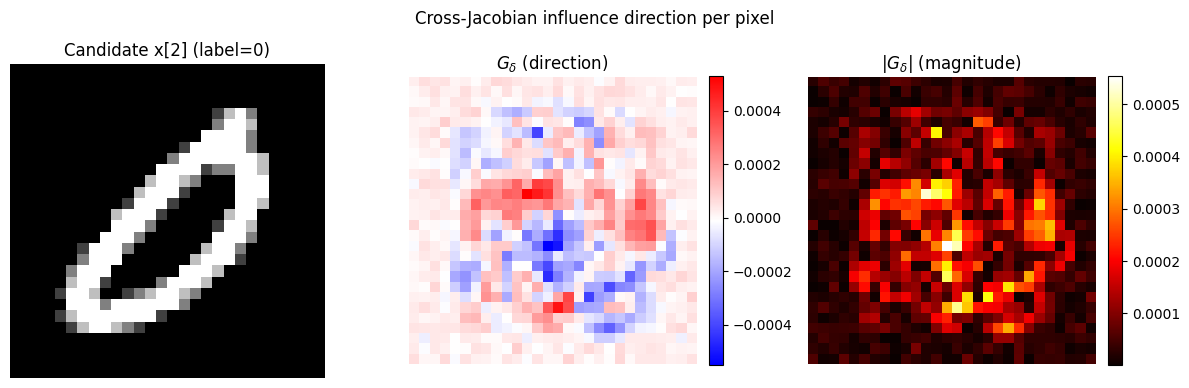

In [9]:
# Take a small batch of training points as "candidates"
cand_B = 16
cand_x = X_tensor[:cand_B]
cand_y = y_tensor[:cand_B]

G_delta = G_delta_batch(model, cand_x, cand_y, v_list, n_train=N)   # [B, 784]
print("G_delta shape:", G_delta.shape)

# Visualize for the first candidate
k = 2
g_img = G_delta[k].detach().cpu().reshape(28, 28)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(cand_x[k].cpu().reshape(28,28), cmap='gray')
plt.title(f"Candidate x[{k}] (label={target_classes[cand_y[k].item()]})")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(g_img, cmap='bwr')
plt.title(r"$G_\delta$ (direction)")
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(g_img.abs(), cmap='hot')
plt.title(r"$|G_\delta|$ (magnitude)")
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')
plt.suptitle("Cross-Jacobian influence direction per pixel")
plt.tight_layout()
plt.show()

In [10]:


# %%
def batch_influence_scores(model, x_batch, y_batch, v_list):
    """
    Returns influence scores v^T ∇θ L(x_i, y_i) for each example i in the batch.
    Uses per-sample gradients via a trick with a weighted sum.
    For exact per-sample grads, consider functorch/backpack; here we do
    a simple approximation by splitting into micro-batches of size 1.
    """
    params = params_of(model)
    scores = []
    for i in range(x_batch.size(0)):
        xb = x_batch[i:i+1].detach()
        yb = y_batch[i:i+1].detach()
        logits = model(xb)
        loss = F.cross_entropy(logits, yb, reduction='sum')
        g_list = torch.autograd.grad(loss, params, retain_graph=False, create_graph=False)
        s = sum((gi * vi).sum() for gi, vi in zip(g_list, v_list))
        scores.append(s.item())
    return np.array(scores)

# Example: score first 64 training points
cand_x2 = X_tensor[:64]
cand_y2 = y_tensor[:64]
scores = batch_influence_scores(model, cand_x2, cand_y2, v_list)
topk = scores.argsort()[::-1][:10]
print("Top-10 most positive v^T ∇θ L(x):", topk)
print("Scores:", scores[topk])



Top-10 most positive v^T ∇θ L(x): [42 57 25 32 21 13 60 20 27 44]
Scores: [17.03843689 13.23148346  4.33746958  4.05454016  3.81615615  3.66935897
  3.54630089  3.2422564   2.70233583  2.35038185]


Reducing dimensions with PCA then t-SNE...
t-SNE embedding shape: (900, 2)
Explained variance by first 50 PCA components: 88.07%


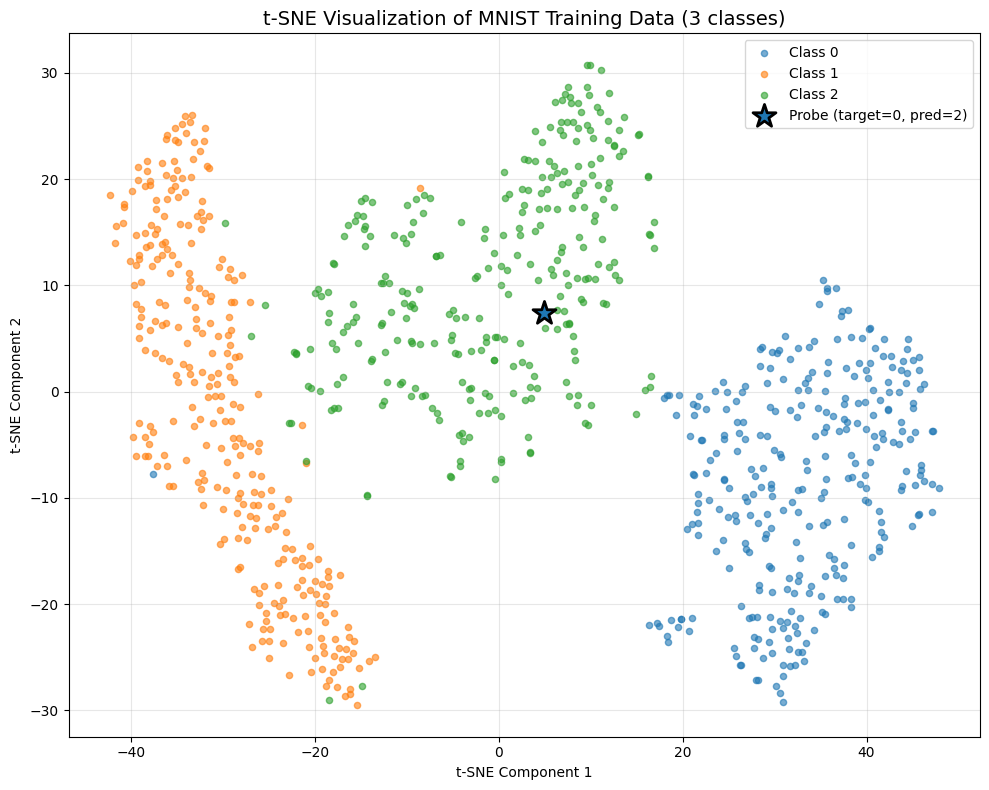

In [11]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# First, reduce dimensions using PCA to speed up t-SNE
print("Reducing dimensions with PCA then t-SNE...")
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X.cpu().numpy())

# Then apply t-SNE for final 2D visualization
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, n_iter=1000)
X_2d = tsne.fit_transform(X_pca)

print(f"t-SNE embedding shape: {X_2d.shape}")
print(f"Explained variance by first 50 PCA components: {pca.explained_variance_ratio_.sum():.2%}")

# Get probe's current prediction
with torch.no_grad():
    probe_logits = model(x_star.unsqueeze(0))
    probe_pred_class = torch.argmax(probe_logits, dim=1).item()

# Visualize the clustering
plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i in range(n_classes):
    mask = y.cpu().numpy() == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], 
               c=colors[i], label=f'Class {target_classes[i]}', 
               alpha=0.6, s=20)

# Add probe point (using nearest neighbor approximation)
x_star_pca_initial = pca.transform(x_star.cpu().numpy().reshape(1, -1))
from scipy.spatial.distance import cdist
distances_init = cdist(x_star_pca_initial, X_pca, metric='euclidean')
nearest_idx_init = np.argmin(distances_init)
x_star_2d_initial = X_2d[nearest_idx_init]

# Color by target class
probe_color = colors[class_star]
plt.scatter(x_star_2d_initial[0], x_star_2d_initial[1], c=probe_color, marker='*', 
           s=300, edgecolors='black', linewidths=2, 
           label=f'Probe (target={class_star}, pred={probe_pred_class})', zorder=15)

plt.title('t-SNE Visualization of MNIST Training Data (3 classes)', fontsize=14)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Compute perturbations for a batch of points using PGD
EPSILON = 2.0      # L-inf perturbation budget (scaled for normalized MNIST)
ALPHA = 0.3        # Step size for PGD
P_NORM = "inf"     # "inf" or "2"
N_STEPS = 20       # Number of PGD steps
BATCH_SIZE = 64    # Number of points to perturb

# Select a batch of training points to perturb
torch.manual_seed(42)
perm_vis = torch.randperm(N)
S_idx = perm_vis[:BATCH_SIZE]

print(f"Perturbing {BATCH_SIZE} training points...")
print(f"Perturbation budget: ε={EPSILON} (L-{P_NORM} norm)")

# Projection operators
def proj_linf(x0, x_candidate, eps):
    return torch.clamp(x_candidate, x0 - eps, x0 + eps)

def proj_l2(x0, x_candidate, eps):
    d = x_candidate - x0
    n = torch.norm(d.reshape(d.shape[0], -1), p=2, dim=1, keepdim=True)
    scale = torch.clamp(eps / (n + 1e-12), max=1.0)
    return x0 + d * scale.reshape(-1, *([1]*(d.ndim-1)))

# Initialize adversarial examples
X0_batch = X_tensor[S_idx].clone()
y_batch = y_tensor[S_idx]
X_adv = X0_batch.clone()

# PGD iterations
for step in range(N_STEPS):
    # Compute G_delta for current batch
    G_delta_current = G_delta_batch(model, X_adv, y_batch, v_list, n_train=N)
    
    # PGD step for each example
    if P_NORM == "inf":
        step_vec = ALPHA * torch.sign(G_delta_current)
        cand = X_adv + step_vec
        X_adv = proj_linf(X0_batch, cand, EPSILON)
    else:  # L2
        gnorm = torch.norm(G_delta_current.reshape(BATCH_SIZE, -1), p=2, dim=1, keepdim=True) + 1e-12
        step_vec = ALPHA * (G_delta_current / gnorm.reshape(-1, 1))
        cand = X_adv + step_vec
        X_adv = proj_l2(X0_batch, cand, EPSILON)

# Compute perturbation norms
pert_norms = torch.norm((X_adv - X0_batch).reshape(BATCH_SIZE, -1), p=float('inf') if P_NORM=='inf' else 2, dim=1)
print(f"Perturbation norms - mean: {pert_norms.mean():.4f}, max: {pert_norms.max():.4f}")

Perturbing 64 training points...
Perturbation budget: ε=2.0 (L-inf norm)
Perturbation norms - mean: 2.0000, max: 2.0000


In [13]:
# Get probe probability BEFORE retraining
with torch.no_grad():
    logits_before = model(x_star.unsqueeze(0))
    probs_before = F.softmax(logits_before, dim=1)[0]
    prob_target_before = probs_before[class_star].item()

print(f"BEFORE perturbation & retrain:")
print(f"  Probe probabilities: {probs_before.cpu().numpy()}")
print(f"  Probability for target class {class_star}: {prob_target_before:.6f}")

# Create modified dataset: replace perturbed points
X_modified = X_tensor.clone()
X_modified[S_idx] = X_adv
y_modified = y_tensor  # Labels unchanged

# Retrain model from scratch on modified dataset
print(f"\n{'='*60}")
print(f"Retraining model from scratch on modified dataset...")
print(f"{'='*60}")

model_retrained, _, _ = train_model(
    X_modified, y_modified, D, n_classes,
    batch_size=B, lr=0.01, epochs=200, device=device, verbose=True
)

print(f"\nRetrain complete!")

# Get probe probability AFTER retraining
with torch.no_grad():
    logits_after = model_retrained(x_star.unsqueeze(0))
    probs_after = F.softmax(logits_after, dim=1)[0]
    prob_target_after = probs_after[class_star].item()

print(f"\nAFTER perturbation & retrain:")
print(f"  Probe probabilities: {probs_after.cpu().numpy()}")
print(f"  Probability for target class {class_star}: {prob_target_after:.6f}")

# Report the change
delta_prob = prob_target_after - prob_target_before
print(f"\n{'='*60}")
print(f"RESULT: Change in probe probability for target class {class_star}:")
print(f"  ΔP = {delta_prob:+.6f} ({delta_prob*100:+.4f}%)")
print(f"  Direction: {'INCREASED ✓' if delta_prob > 0 else 'DECREASED ✗'}")
print(f"{'='*60}")

BEFORE perturbation & retrain:
  Probe probabilities: [3.7895679e-04 7.0463524e-10 9.9962103e-01]
  Probability for target class 0: 0.000379

Retraining model from scratch on modified dataset...
Epoch 0: Loss = 0.1473, Acc = 0.9667
Epoch 100: Loss = 0.0095, Acc = 1.0000

Retrain complete!

AFTER perturbation & retrain:
  Probe probabilities: [3.1292725e-02 1.5167982e-08 9.6870732e-01]
  Probability for target class 0: 0.031293

RESULT: Change in probe probability for target class 0:
  ΔP = +0.030914 (+3.0914%)
  Direction: INCREASED ✓


In [14]:
# Compute trajectory in 2D space for visualization
print("Computing trajectory in 2D space...")

# Store trajectory during PGD
trajectory = []

# Re-run PGD but save intermediate steps
X_adv_traj = X0_batch.clone()
for step in range(N_STEPS + 1):  # +1 to include initial position
    # Save current position
    trajectory.append(X_adv_traj.detach().cpu().numpy())
    
    if step < N_STEPS:  # Don't perturb on last iteration
        # Compute G_delta for current batch
        G_delta_current = G_delta_batch(model, X_adv_traj, y_batch, v_list, n_train=N)
        
        # PGD step
        if P_NORM == "inf":
            step_vec = ALPHA * torch.sign(G_delta_current)
            cand = X_adv_traj + step_vec
            X_adv_traj = proj_linf(X0_batch, cand, EPSILON)
        else:  # L2
            gnorm = torch.norm(G_delta_current.reshape(BATCH_SIZE, -1), p=2, dim=1, keepdim=True) + 1e-12
            step_vec = ALPHA * (G_delta_current / gnorm.reshape(-1, 1))
            cand = X_adv_traj + step_vec
            X_adv_traj = proj_l2(X0_batch, cand, EPSILON)

# Convert trajectory to 2D using the same PCA and t-SNE transformations
# For visualization, we use a fixed t-SNE on the full dataset
X_2d_vis = X_2d  # Use existing t-SNE from earlier

# Project trajectory points to 2D (approximate using nearest neighbors)
trajectory_2d = []
for traj_step in trajectory:
    # Transform to PCA space
    traj_pca = pca.transform(traj_step)
    # Find nearest neighbor in original PCA space for each point
    traj_2d_step = []
    for i in range(len(traj_pca)):
        from scipy.spatial.distance import cdist
        dist = cdist(traj_pca[i:i+1], X_pca, metric='euclidean')
        nearest_idx = np.argmin(dist)
        traj_2d_step.append(X_2d[nearest_idx])
    trajectory_2d.append(np.array(traj_2d_step))

# Compute probe's 2D position (using nearest neighbor)
x_star_pca = pca.transform(x_star.cpu().numpy().reshape(1, -1))
from scipy.spatial.distance import cdist
distances_probe = cdist(x_star_pca, X_pca, metric='euclidean')
nearest_idx_probe = np.argmin(distances_probe)
x_star_2d = X_2d[nearest_idx_probe:nearest_idx_probe+1]

print(f"Trajectory computed: {len(trajectory_2d)} steps")
print(f"Trajectory shape: {len(trajectory_2d)} x {trajectory_2d[0].shape}")

Computing trajectory in 2D space...
Trajectory computed: 21 steps
Trajectory shape: 21 x (64, 2)


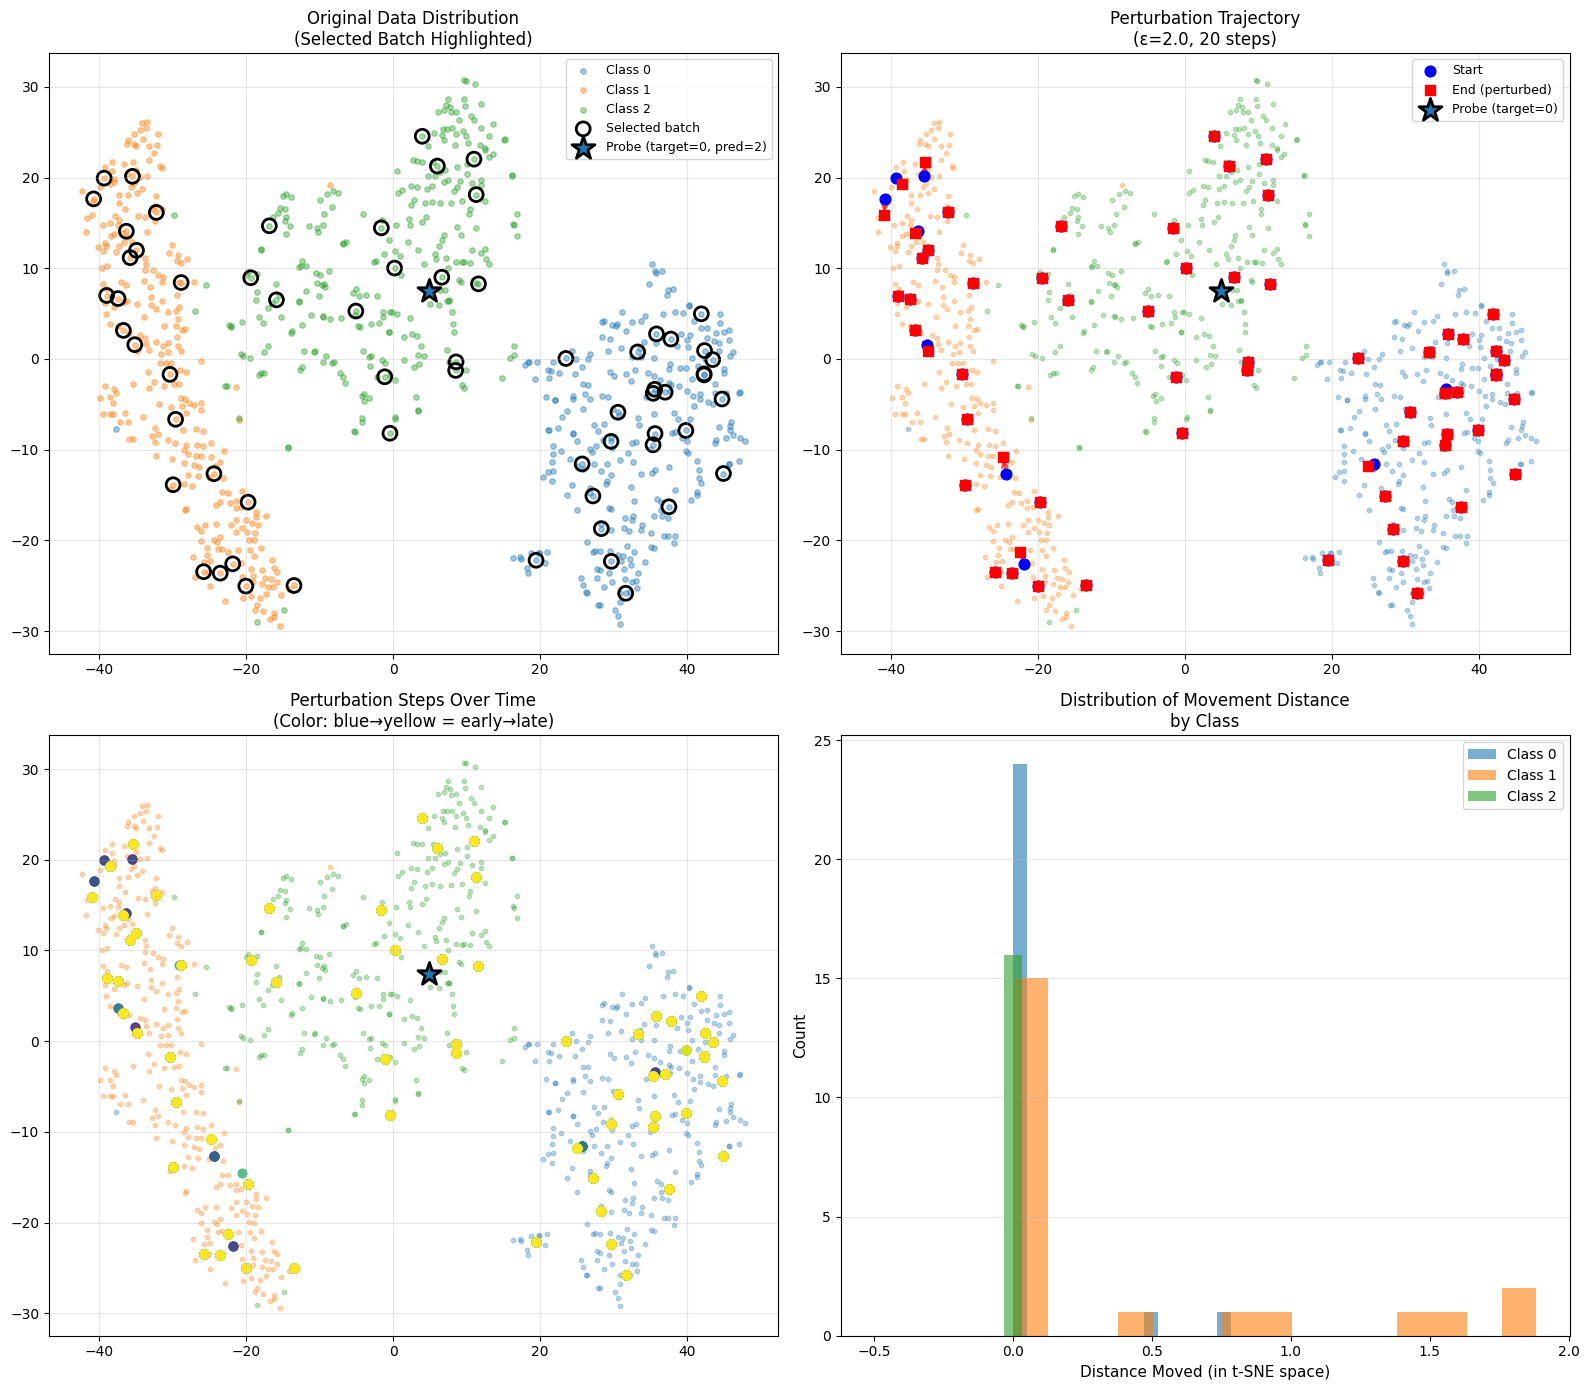


Movement statistics:
  Mean distance: 0.159
  Max distance: 1.883
  Min distance: 0.000

Probe info:
  Target class: 0
  Current prediction: 2
  Probe colored by: TARGET class (not prediction)


In [16]:
# Visualize the perturbation trajectory
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Get indices in 2D space
S_idx_cpu = S_idx.cpu().numpy()

# Get probe's current prediction
with torch.no_grad():
    probe_logits = model(x_star.unsqueeze(0))
    probe_pred_class = torch.argmax(probe_logits, dim=1).item()

# Probe color based on TARGET class (not prediction)
probe_color = colors[class_star]

# Plot 1: Original clustering with selected batch highlighted
ax = axes[0, 0]
for i in range(n_classes):
    mask = y.cpu().numpy() == i
    ax.scatter(X_2d_vis[mask, 0], X_2d_vis[mask, 1], 
              c=colors[i], label=f'Class {target_classes[i]}', 
              alpha=0.4, s=15)

# Highlight selected batch
ax.scatter(X_2d_vis[S_idx_cpu, 0], X_2d_vis[S_idx_cpu, 1],
          facecolors='none', edgecolors='black', s=100, linewidths=2,
          label='Selected batch')

# Add probe point (colored by TARGET class)
ax.scatter(x_star_2d[0, 0], x_star_2d[0, 1], c=probe_color, marker='*', 
          s=300, edgecolors='black', linewidths=2, 
          label=f'Probe (target={class_star}, pred={probe_pred_class})', zorder=15)

ax.set_title('Original Data Distribution\n(Selected Batch Highlighted)', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Perturbation trajectory with arrows
ax = axes[0, 1]
for i in range(n_classes):
    mask = y.cpu().numpy() == i
    ax.scatter(X_2d_vis[mask, 0], X_2d_vis[mask, 1], 
              c=colors[i], alpha=0.3, s=10)

# Draw arrows showing movement
for i in range(len(S_idx_cpu)):
    start = trajectory_2d[0][i]  # First position
    end = trajectory_2d[-1][i]   # Final position
    ax.annotate('', xy=end, xytext=start,
               arrowprops=dict(arrowstyle='->', color='red', lw=1.5, alpha=0.7))

# Plot start and end positions
ax.scatter(trajectory_2d[0][:, 0], trajectory_2d[0][:, 1],
          c='blue', s=60, marker='o', label='Start', zorder=5)
ax.scatter(trajectory_2d[-1][:, 0], trajectory_2d[-1][:, 1],
          c='red', s=60, marker='s', label='End (perturbed)', zorder=5)

# Add probe point (colored by TARGET class)
ax.scatter(x_star_2d[0, 0], x_star_2d[0, 1], c=probe_color, marker='*', 
          s=300, edgecolors='black', linewidths=2, 
          label=f'Probe (target={class_star})', zorder=15)

ax.set_title(f'Perturbation Trajectory\n(ε={EPSILON}, {N_STEPS} steps)', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 3: Show intermediate steps
ax = axes[1, 0]
for i in range(n_classes):
    mask = y.cpu().numpy() == i
    ax.scatter(X_2d_vis[mask, 0], X_2d_vis[mask, 1], 
              c=colors[i], alpha=0.3, s=10)

# Plot trajectory with color gradient
n_traj = len(trajectory_2d)
cmap = plt.cm.viridis
for t_idx, traj_point in enumerate(trajectory_2d):
    alpha_val = 0.3 + 0.7 * (t_idx / (n_traj - 1))
    color_val = cmap(t_idx / (n_traj - 1))
    ax.scatter(traj_point[:, 0], traj_point[:, 1],
              c=[color_val], s=40, alpha=alpha_val, 
              label=f'Step {t_idx*5}' if t_idx % 2 == 0 else '')

# Add probe point (colored by TARGET class)
ax.scatter(x_star_2d[0, 0], x_star_2d[0, 1], c=probe_color, marker='*', 
          s=300, edgecolors='black', linewidths=2, 
          label=f'Probe (target={class_star})', zorder=15)

ax.set_title('Perturbation Steps Over Time\n(Color: blue→yellow = early→late)', fontsize=12)
if n_traj <= 6:
    ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 4: Distance moved in embedding space
ax = axes[1, 1]
distances = []
for i in range(len(S_idx_cpu)):
    dist = np.linalg.norm(trajectory_2d[-1][i] - trajectory_2d[0][i])
    distances.append(dist)

batch_labels = y_batch.cpu().numpy()
for i in range(n_classes):
    mask = batch_labels == i
    if mask.sum() > 0:
        ax.hist(np.array(distances)[mask], bins=15, alpha=0.6, 
               label=f'Class {target_classes[i]}', color=colors[i])

ax.set_xlabel('Distance Moved (in t-SNE space)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution of Movement Distance\nby Class', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nMovement statistics:")
print(f"  Mean distance: {np.mean(distances):.3f}")
print(f"  Max distance: {np.max(distances):.3f}")
print(f"  Min distance: {np.min(distances):.3f}")
print(f"\nProbe info:")
print(f"  Target class: {class_star}")
print(f"  Current prediction: {probe_pred_class}")
print(f"  Probe colored by: TARGET class (not prediction)")